# Step 5: Visualization & Analysis

## Plots produced
| # | Plot | Description |
|---|---|---|
| 5.1 | **Novelty Over Time** | Structural + semantic + disruptiveness trends per year, split by SKG/NOVEL/BLOG |
| 5.2 | **Score Distributions** | KDE + histogram of all novelty scores by split |
| 5.3 | **Citation Network Snapshots** | NetworkX graph for selected years, nodes coloured by disruptiveness |
| 5.4 | **t-SNE Cluster Map** | Abstract embedding space coloured by `disruption_class` and domain |
| 5.5 | **TransE vs TGN Scatter** | Two-axis unexpectedness space with disruption class overlay |
| 5.6 | **Top-20 Disruptive Papers** | Bar chart of most disruptive NOVEL papers |
| 5.7 | **Domain-level Novelty Heatmap** | Mean disruptiveness per domain × year |

**Inputs required in same directory as notebook:**
- `novelty_feature_matrix_with_score.csv` (Step 4 output — 24 cols)
- `paper_nodes.csv`
- `citation_edges.csv`
- `citation_edges_2022_2025.csv`
- `abstract_embeddings.npy`
- `paper_ids.npy`
- `combined_disruptiveness.csv`

## Cell 0 — Imports & Style Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import networkx as nx
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import os

# ── Output directory ──────────────────────────────────────────────────────────
OUT_DIR = '../../outputs/visuals'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 150,
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#e6edf3',
    'axes.titlecolor'  : '#e6edf3',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#e6edf3',
    'grid.color'       : '#21262d',
    'grid.linewidth'   : 0.6,
    'legend.facecolor' : '#161b22',
    'legend.edgecolor' : '#30363d',
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
})

# ── Color palettes ────────────────────────────────────────────────────────────
CLASS_COLORS = {
    'DISRUPTIVE'   : '#f78166',   # red-orange
    'TRANSITIONAL' : '#e3b341',   # amber
    'INCREMENTAL'  : '#3fb950',   # green
}
SPLIT_COLORS = {
    'SKG'   : '#58a6ff',   # blue
    'NOVEL' : '#f78166',   # orange-red
    'BLOG'  : '#bc8cff',   # purple
}
DOMAIN_PALETTE = [
    '#58a6ff','#f78166','#3fb950','#e3b341',
    '#bc8cff','#79c0ff','#ffa657','#56d364',
]

def save(name):
    path = f'{OUT_DIR}/{name}'
    plt.savefig(path, bbox_inches='tight', facecolor=plt.rcParams['figure.facecolor'])
    plt.show()
    print(f'  ✓ saved → {path}')

print('Style configured. Output directory:', OUT_DIR)

Style configured. Output directory: ../../outputs/visuals


## Cell 1 — Load Data

In [4]:
# ── Core feature matrix ───────────────────────────────────────────────────────
df = pd.read_csv('../../outputs/final/novelty_feature_matrix_with_score.csv')
print(f'Feature matrix: {df.shape}  cols: {df.columns.tolist()}')

# ── Paper metadata (domain, split, year) ──────────────────────────────────────
pn = pd.read_csv('../../outputs/final/paper_nodes.csv')
df = df.merge(pn[['node_id','domain','split']].rename(columns={'node_id':'paper_id'}),
              on='paper_id', how='left')

# Fill split from paper_id prefix if missing
def infer_split(pid):
    if str(pid).startswith('NOVEL'): return 'NOVEL'
    if str(pid).startswith('BLOG'):  return 'BLOG'
    return 'SKG'
df['split'] = df['split'].fillna(df['paper_id'].map(infer_split))

# Infer domain from paper_id (e.g. NOVEL_DIA_0 → DIA)
df['domain'] = df['domain'].fillna(
    df['paper_id'].str.split('_').str[1].where(
        df['paper_id'].str.split('_').str.len() >= 2, 'UNK'
    )
)

# ── Citation edges ────────────────────────────────────────────────────────────
cite_hist   = pd.read_csv('../../outputs/other/citation_edges.csv')
cite_recent = pd.read_csv('../../outputs/other/citation_edges_2022_2025.csv')
cite_all    = pd.concat([cite_hist, cite_recent], ignore_index=True)

# ── Abstract embeddings ───────────────────────────────────────────────────────
abstract_emb = np.load('../../outputs/final/abstract_embeddings.npy', allow_pickle=True).astype(np.float32)
paper_ids    = np.load('../../outputs/final/paper_ids.npy', allow_pickle=True)

# ── Combined disruptiveness (NOVEL only) ──────────────────────────────────────
combined = pd.read_csv('../../outputs/final/combined_disruptiveness.csv')

# ── Convenience subsets ───────────────────────────────────────────────────────
df_novel = df[df['split'] == 'NOVEL'].copy()
df_skg   = df[df['split'] == 'SKG'].copy()
df_blog  = df[df['split'] == 'BLOG'].copy()

print(f'  SKG: {len(df_skg)} | NOVEL: {len(df_novel)} | BLOG: {len(df_blog)}')
print(f'  Domains: {sorted(df["domain"].dropna().unique())}')
print(f'  Year range: {df["year"].min():.0f} – {df["year"].max():.0f}')

Feature matrix: (4242, 24)  cols: ['paper_id', 'year', 'semantic_knn', 'structural_novelty', 'triple_count', 'cited_by_count', 'reference_count', 'citation_signal', 'struct_norm', 'semantic_norm', 'citation_norm', 'composite_novelty', 'n_triples', 'mean_dist', 'min_dist', 'pct_unseen_entity', 'pct_unseen_pred', 'transe_unexpectedness', 'n_citations', 'mean_link_prob', 'tgn_unexpectedness', 'kg_unexpectedness', 'disruptiveness', 'disruption_class']
  SKG: 2916 | NOVEL: 762 | BLOG: 564
  Domains: ['DIA', 'MT', 'NLI', 'PAR', 'QA', 'SA', 'SUM']
  Year range: 2010 – 2025


## Cell 2 — Plot 5.1: Novelty Over Time
Mean structural, semantic, and composite novelty per year, split into three sub-panels by corpus split.

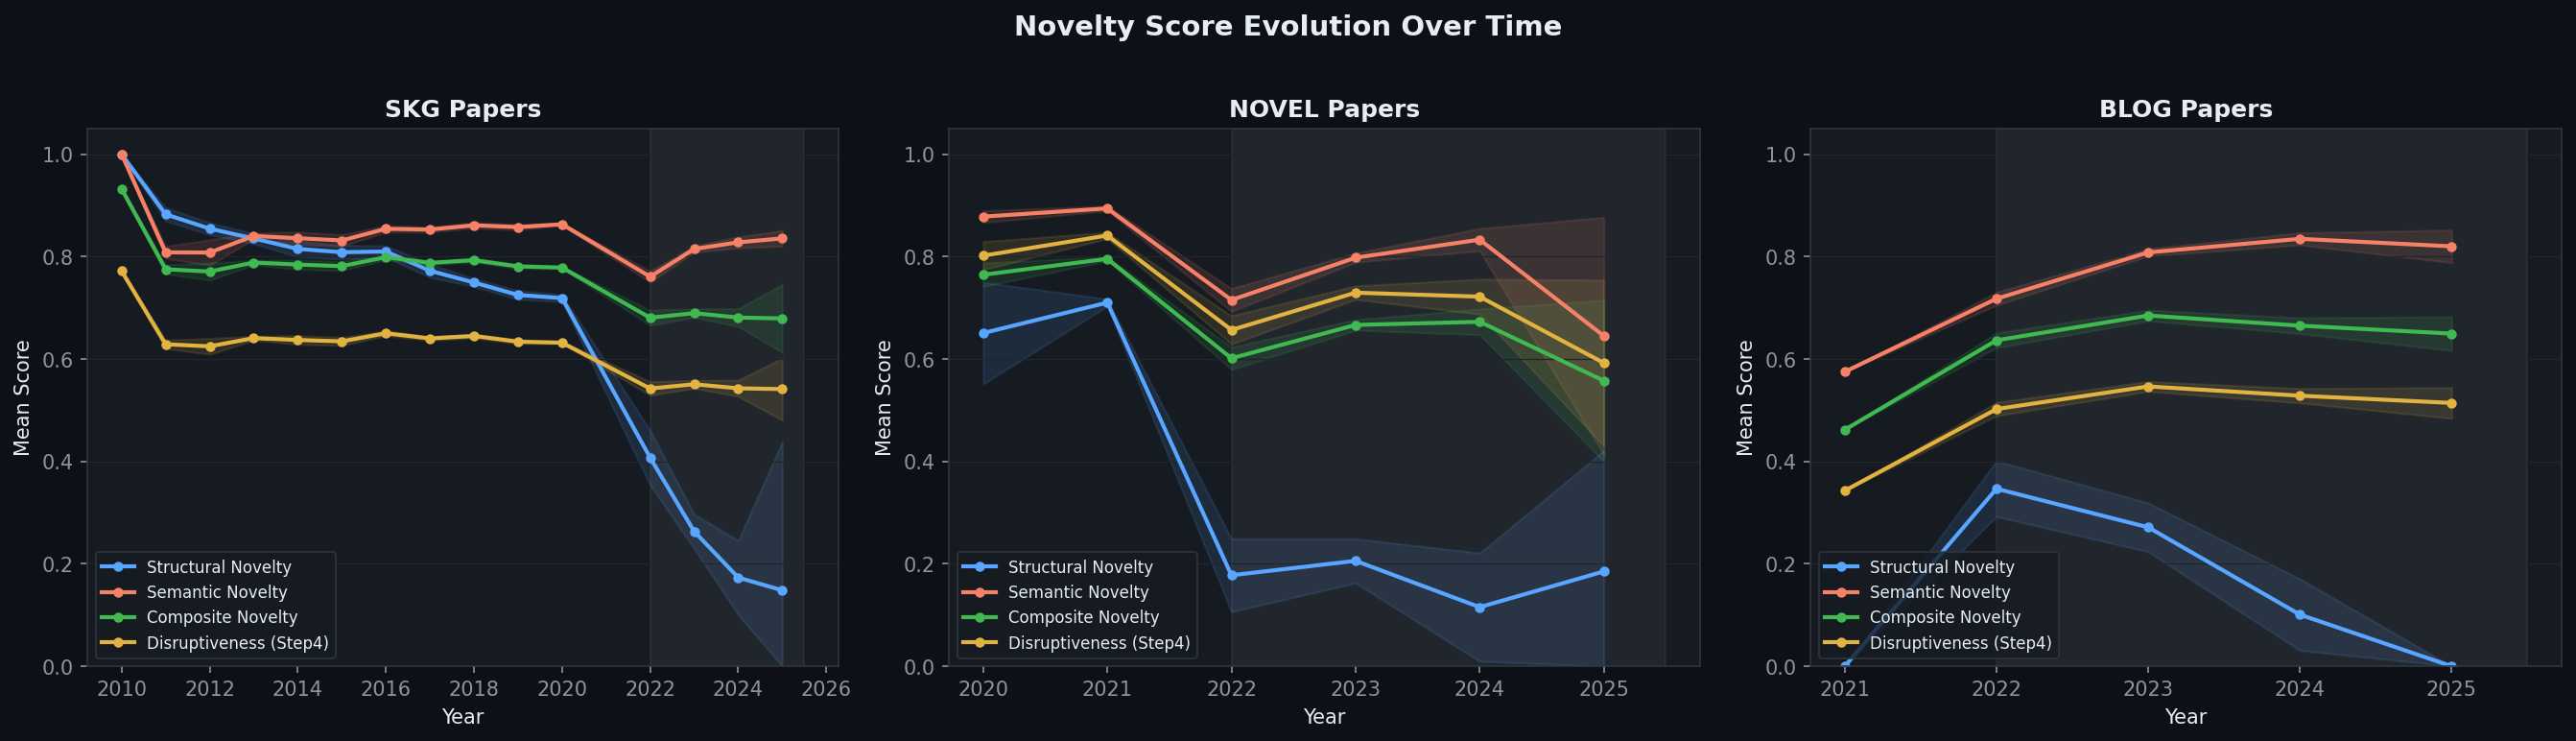

  ✓ saved → ../../outputs/visuals/5_1_novelty_over_time.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle('Novelty Score Evolution Over Time', fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('struct_norm',       'Structural Novelty',   '#58a6ff'),
    ('semantic_norm',     'Semantic Novelty',      '#f78166'),
    ('composite_novelty', 'Composite Novelty',     '#3fb950'),
    ('disruptiveness',    'Disruptiveness (Step4)','#e3b341'),
]

split_labels = ['SKG', 'NOVEL', 'BLOG']
split_data   = [df_skg, df_novel, df_blog]

for ax, label, subset in zip(axes, split_labels, split_data):
    yearly = subset.groupby('year')[[
        'struct_norm','semantic_norm','composite_novelty','disruptiveness'
    ]].mean()

    for col, name, color in metrics:
        if col not in yearly.columns:
            continue
        valid = yearly[col].dropna()
        ax.plot(valid.index, valid.values, color=color, linewidth=2,
                marker='o', markersize=4, label=name)
        # 95% CI via std/sqrt(n)
        std_y = subset.groupby('year')[col].std()
        cnt_y = subset.groupby('year')[col].count()
        ci    = 1.96 * std_y / np.sqrt(cnt_y.clip(lower=1))
        ax.fill_between(valid.index,
                        (valid - ci.reindex(valid.index).fillna(0)).clip(0),
                        (valid + ci.reindex(valid.index).fillna(0)).clip(0, 1),
                        color=color, alpha=0.12)

    ax.set_title(f'{label} Papers')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean Score')
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis='y')
    ax.legend(fontsize=8, loc='lower left')
    # Shade 2022+ as 'recent era'
    ax.axvspan(2022, subset['year'].max() + 0.5,
               alpha=0.05, color='white', label='2022+ era')

plt.tight_layout()
save('5_1_novelty_over_time.png')

## Cell 3 — Plot 5.2: Score Distributions by Split
KDE + rug plots for each novelty metric across SKG / NOVEL / BLOG.

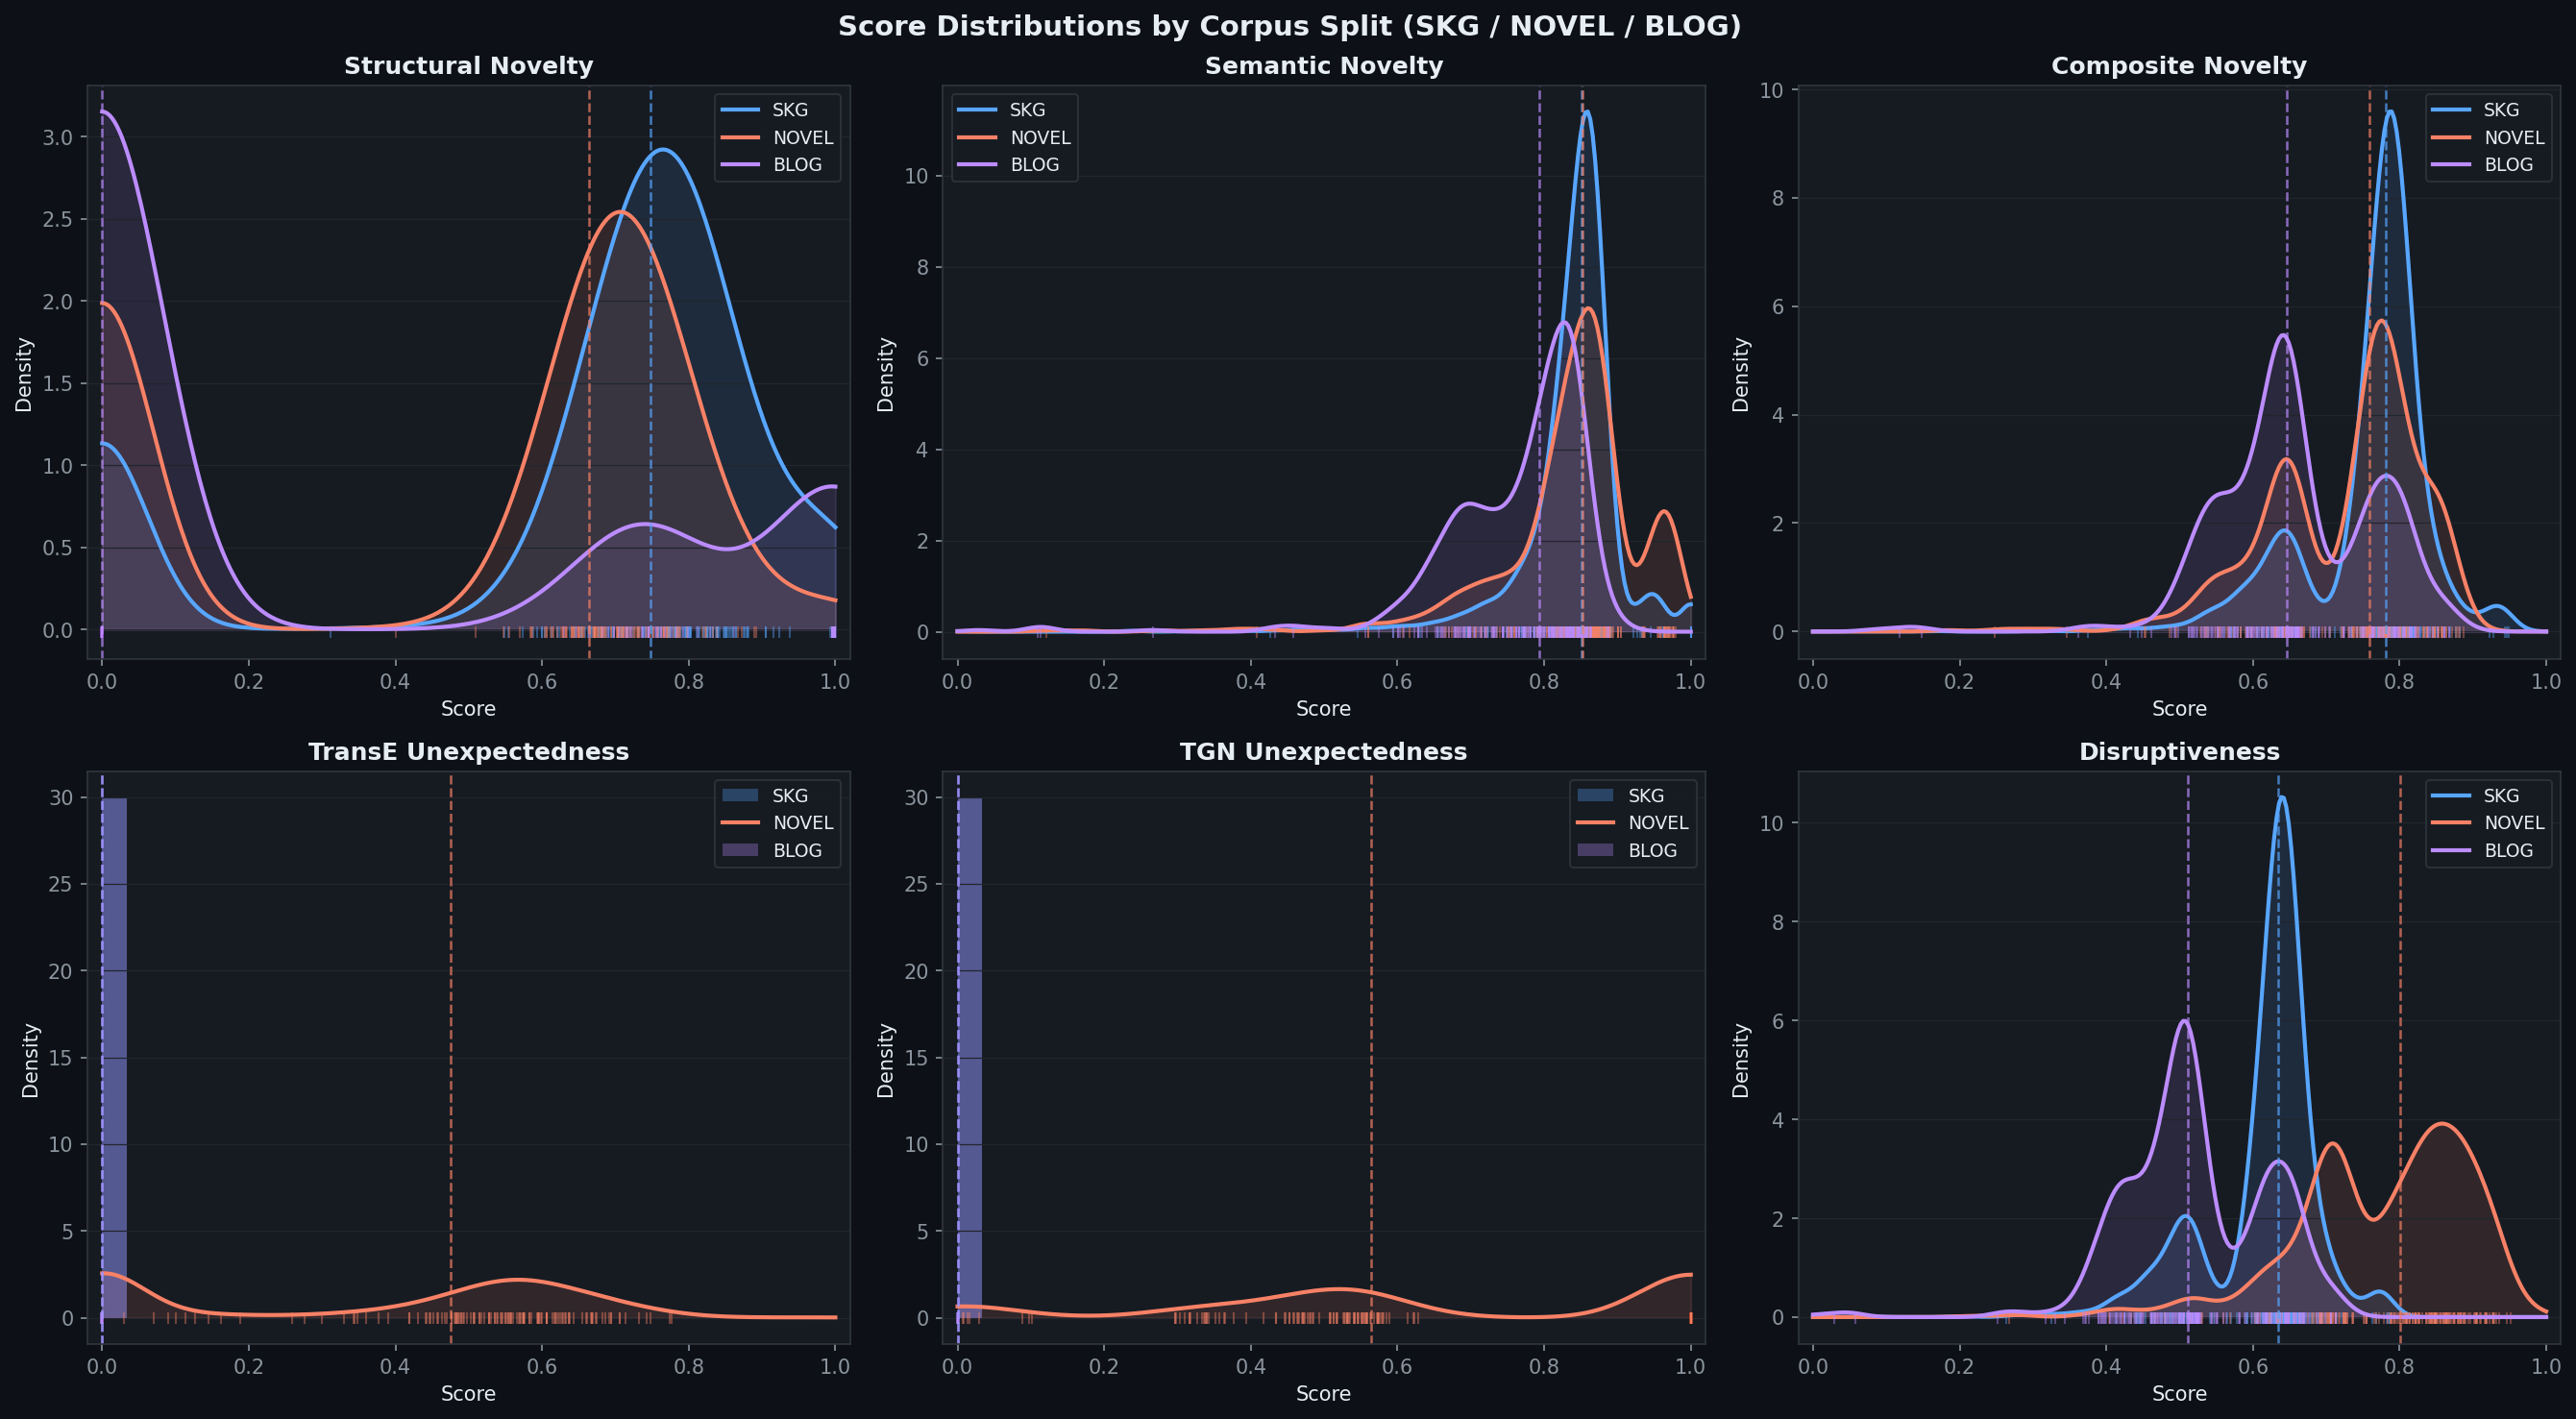

  ✓ saved → ../../outputs/visuals/5_2_score_distributions.png


In [6]:
from scipy.stats import gaussian_kde

plot_cols = [
    ('struct_norm',         'Structural Novelty'),
    ('semantic_norm',       'Semantic Novelty'),
    ('composite_novelty',   'Composite Novelty'),
    ('transe_unexpectedness','TransE Unexpectedness'),
    ('tgn_unexpectedness',  'TGN Unexpectedness'),
    ('disruptiveness',      'Disruptiveness'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Score Distributions by Corpus Split (SKG / NOVEL / BLOG)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

x_range = np.linspace(0, 1, 300)

for ax, (col, title) in zip(axes, plot_cols):
    for split_name, color in SPLIT_COLORS.items():
        vals = df[df['split'] == split_name][col].dropna()
        if len(vals) < 5:
            continue
        # KDE
        try:
            kde  = gaussian_kde(vals, bw_method=0.2)
            density = kde(x_range)
            ax.plot(x_range, density, color=color, linewidth=2, label=split_name)
            ax.fill_between(x_range, density, alpha=0.12, color=color)
        except Exception:
            ax.hist(vals, bins=30, density=True, color=color, alpha=0.3, label=split_name)
        # Rug
        rug_sample = vals.sample(min(len(vals), 200), random_state=42)
        ax.plot(rug_sample, np.zeros_like(rug_sample) - 0.02,
                '|', color=color, alpha=0.4, markersize=6)

    # Vertical median lines
    for split_name, color in SPLIT_COLORS.items():
        vals = df[df['split'] == split_name][col].dropna()
        if len(vals) > 0:
            ax.axvline(vals.median(), color=color, linewidth=1.2,
                       linestyle='--', alpha=0.7)

    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.set_xlim(-0.02, 1.02)
    ax.grid(True, axis='y')
    ax.legend(fontsize=9)

plt.tight_layout()
save('5_2_score_distributions.png')

## Cell 4 — Plot 5.3: Citation Network Snapshots
NetworkX graphs for 3 time snapshots (2018, 2020, 2022). Nodes coloured by `disruptiveness`, sized by `cited_by_count`. Only DIA domain shown for clarity.

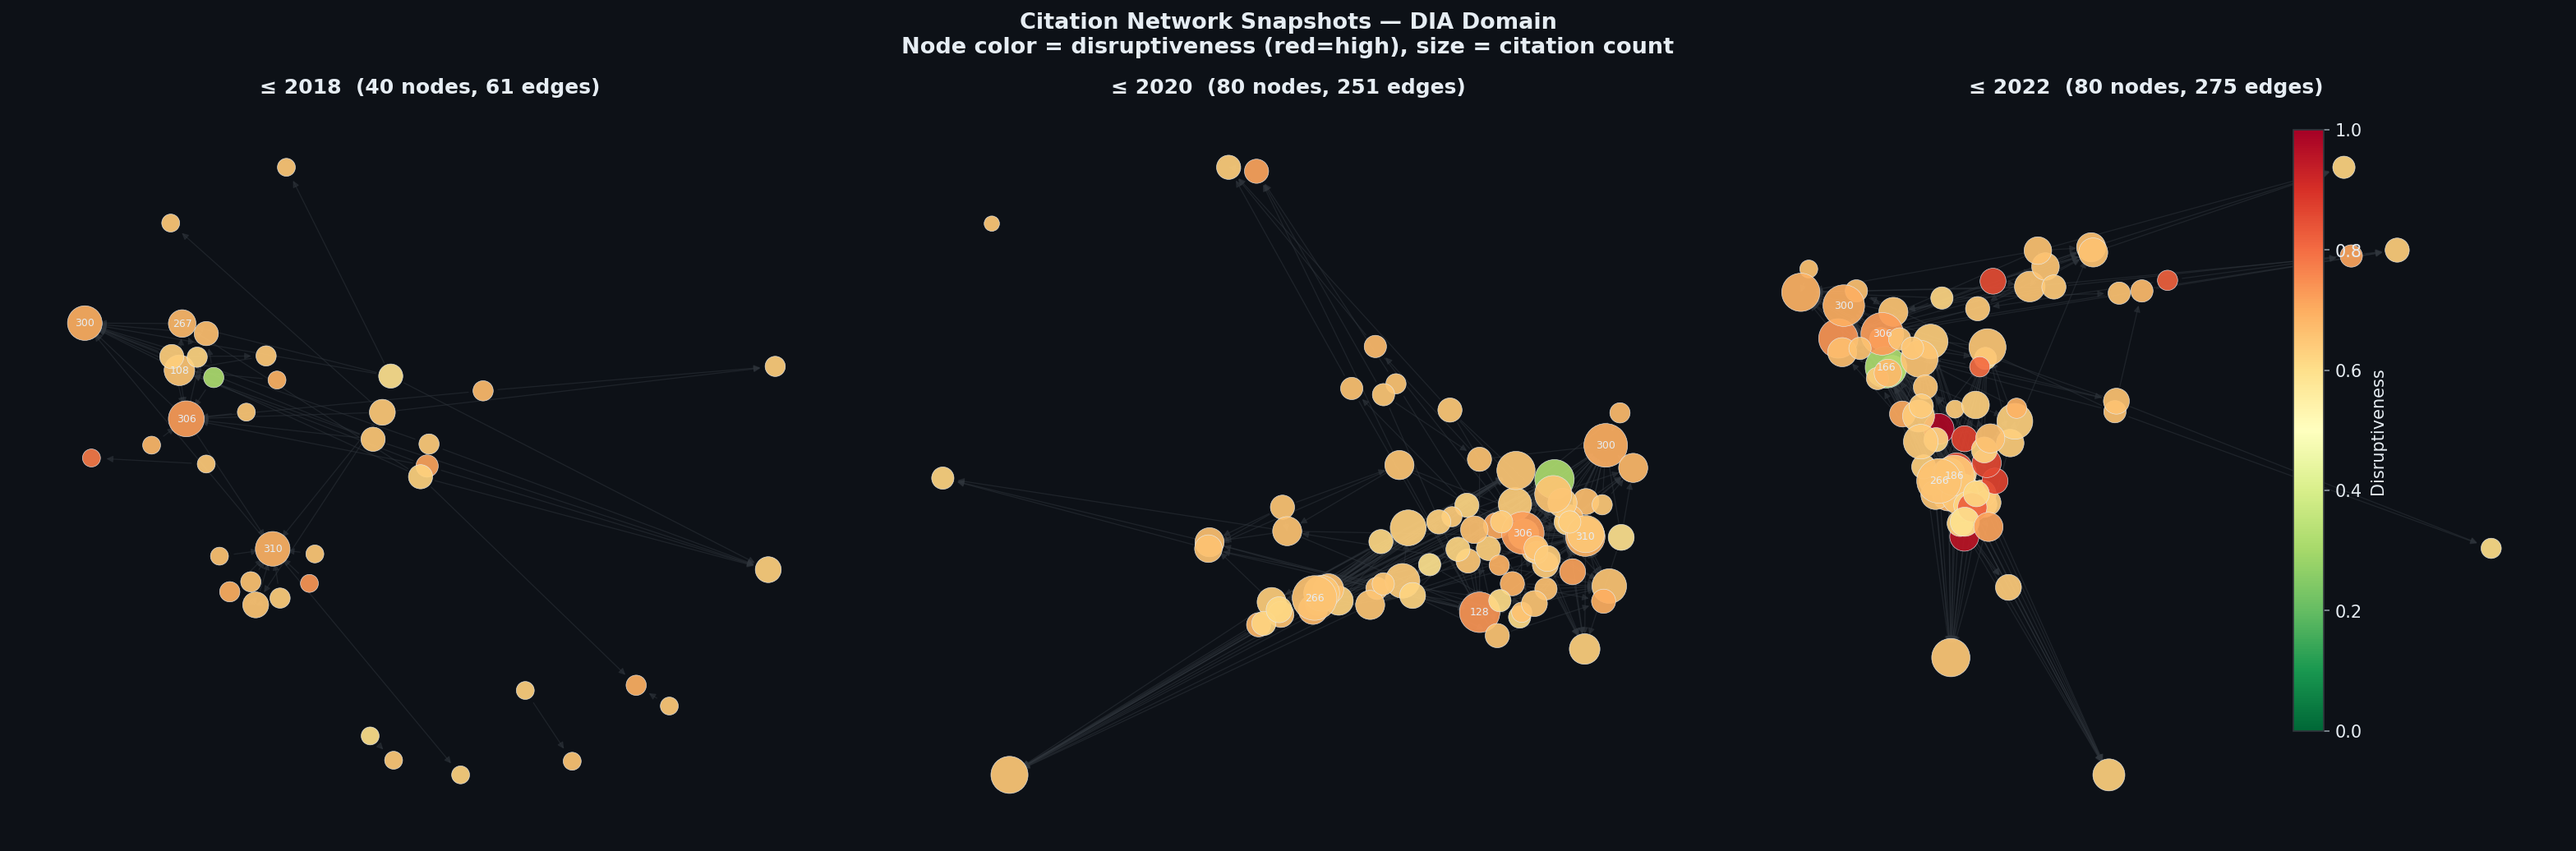

  ✓ saved → ../../outputs/visuals/5_3_citation_network_snapshots.png


In [7]:
TARGET_DOMAIN = 'DIA'   # change to None to use all domains
SNAPSHOT_YEARS = [2018, 2020, 2022]
MAX_NODES = 80          # cap per snapshot for readable layout

# Novelty lookup
novelty_lookup = df.set_index('paper_id')['disruptiveness'].to_dict()
year_lookup    = df.set_index('paper_id')['year'].to_dict()
domain_lookup  = df.set_index('paper_id')['domain'].to_dict()

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f'Citation Network Snapshots — {TARGET_DOMAIN} Domain\n'
             'Node color = disruptiveness (red=high), size = citation count',
             fontsize=13, fontweight='bold')

cmap = plt.cm.RdYlGn_r  # red=disruptive, green=incremental
norm = Normalize(vmin=0, vmax=1)

for ax, snap_year in zip(axes, SNAPSHOT_YEARS):
    # Filter papers up to snapshot year
    papers_upto = df[df['year'] <= snap_year]
    if TARGET_DOMAIN:
        papers_upto = papers_upto[papers_upto['domain'] == TARGET_DOMAIN]
    paper_set = set(papers_upto['paper_id'])

    # Filter citation edges
    edges_snap = cite_all[
        cite_all['source'].isin(paper_set) &
        cite_all['target'].isin(paper_set) &
        (cite_all['year'] <= snap_year)
    ]

    # Build graph
    G = nx.DiGraph()
    G.add_edges_from(zip(edges_snap['source'], edges_snap['target']))

    # Sub-sample if too large
    if len(G.nodes) > MAX_NODES:
        top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:MAX_NODES]
        G = G.subgraph([n for n, _ in top_nodes]).copy()

    if len(G.nodes) == 0:
        ax.set_title(f'{snap_year}\n(no data)')
        ax.axis('off')
        continue

    pos = nx.spring_layout(G, seed=42, k=1.5/max(len(G.nodes)**0.5, 1))

    node_colors = [cmap(norm(novelty_lookup.get(n, 0.5))) for n in G.nodes]
    node_sizes  = [80 + 30 * min(G.degree(n), 20) for n in G.nodes]

    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color='#30363d', arrows=True,
                           arrowsize=8, width=0.6, alpha=0.5)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=node_sizes,
                           alpha=0.92, linewidths=0.3, edgecolors='#e6edf3')

    # Label top-5 nodes by degree
    top5 = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:5]
    labels = {n: n.split('_')[-1] for n, _ in top5}
    nx.draw_networkx_labels(G, pos, labels, ax=ax,
                            font_size=6, font_color='#e6edf3')

    ax.set_title(f'≤ {snap_year}  ({len(G.nodes)} nodes, {len(G.edges)} edges)')
    ax.axis('off')

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                    fraction=0.015, pad=0.02)
cbar.set_label('Disruptiveness', color='#e6edf3')
cbar.ax.yaxis.set_tick_params(color='#8b949e')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#e6edf3')

plt.tight_layout()
save('5_3_citation_network_snapshots.png')

## Cell 5 — Plot 5.4: t-SNE Cluster Map
2D projection of SBERT abstract embeddings. Two views:
- (A) coloured by `disruption_class`
- (B) coloured by `domain`

Running t-SNE on abstract embeddings (this may take 1-3 min)...
  Sub-sampled to 3000 papers for t-SNE
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.002s...
[t-SNE] Computed neighbors for 3000 samples in 3.442s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 1.497704
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.855865
[t-SNE] KL divergence after 1000 iterations: 1.544101
t-SNE complete.


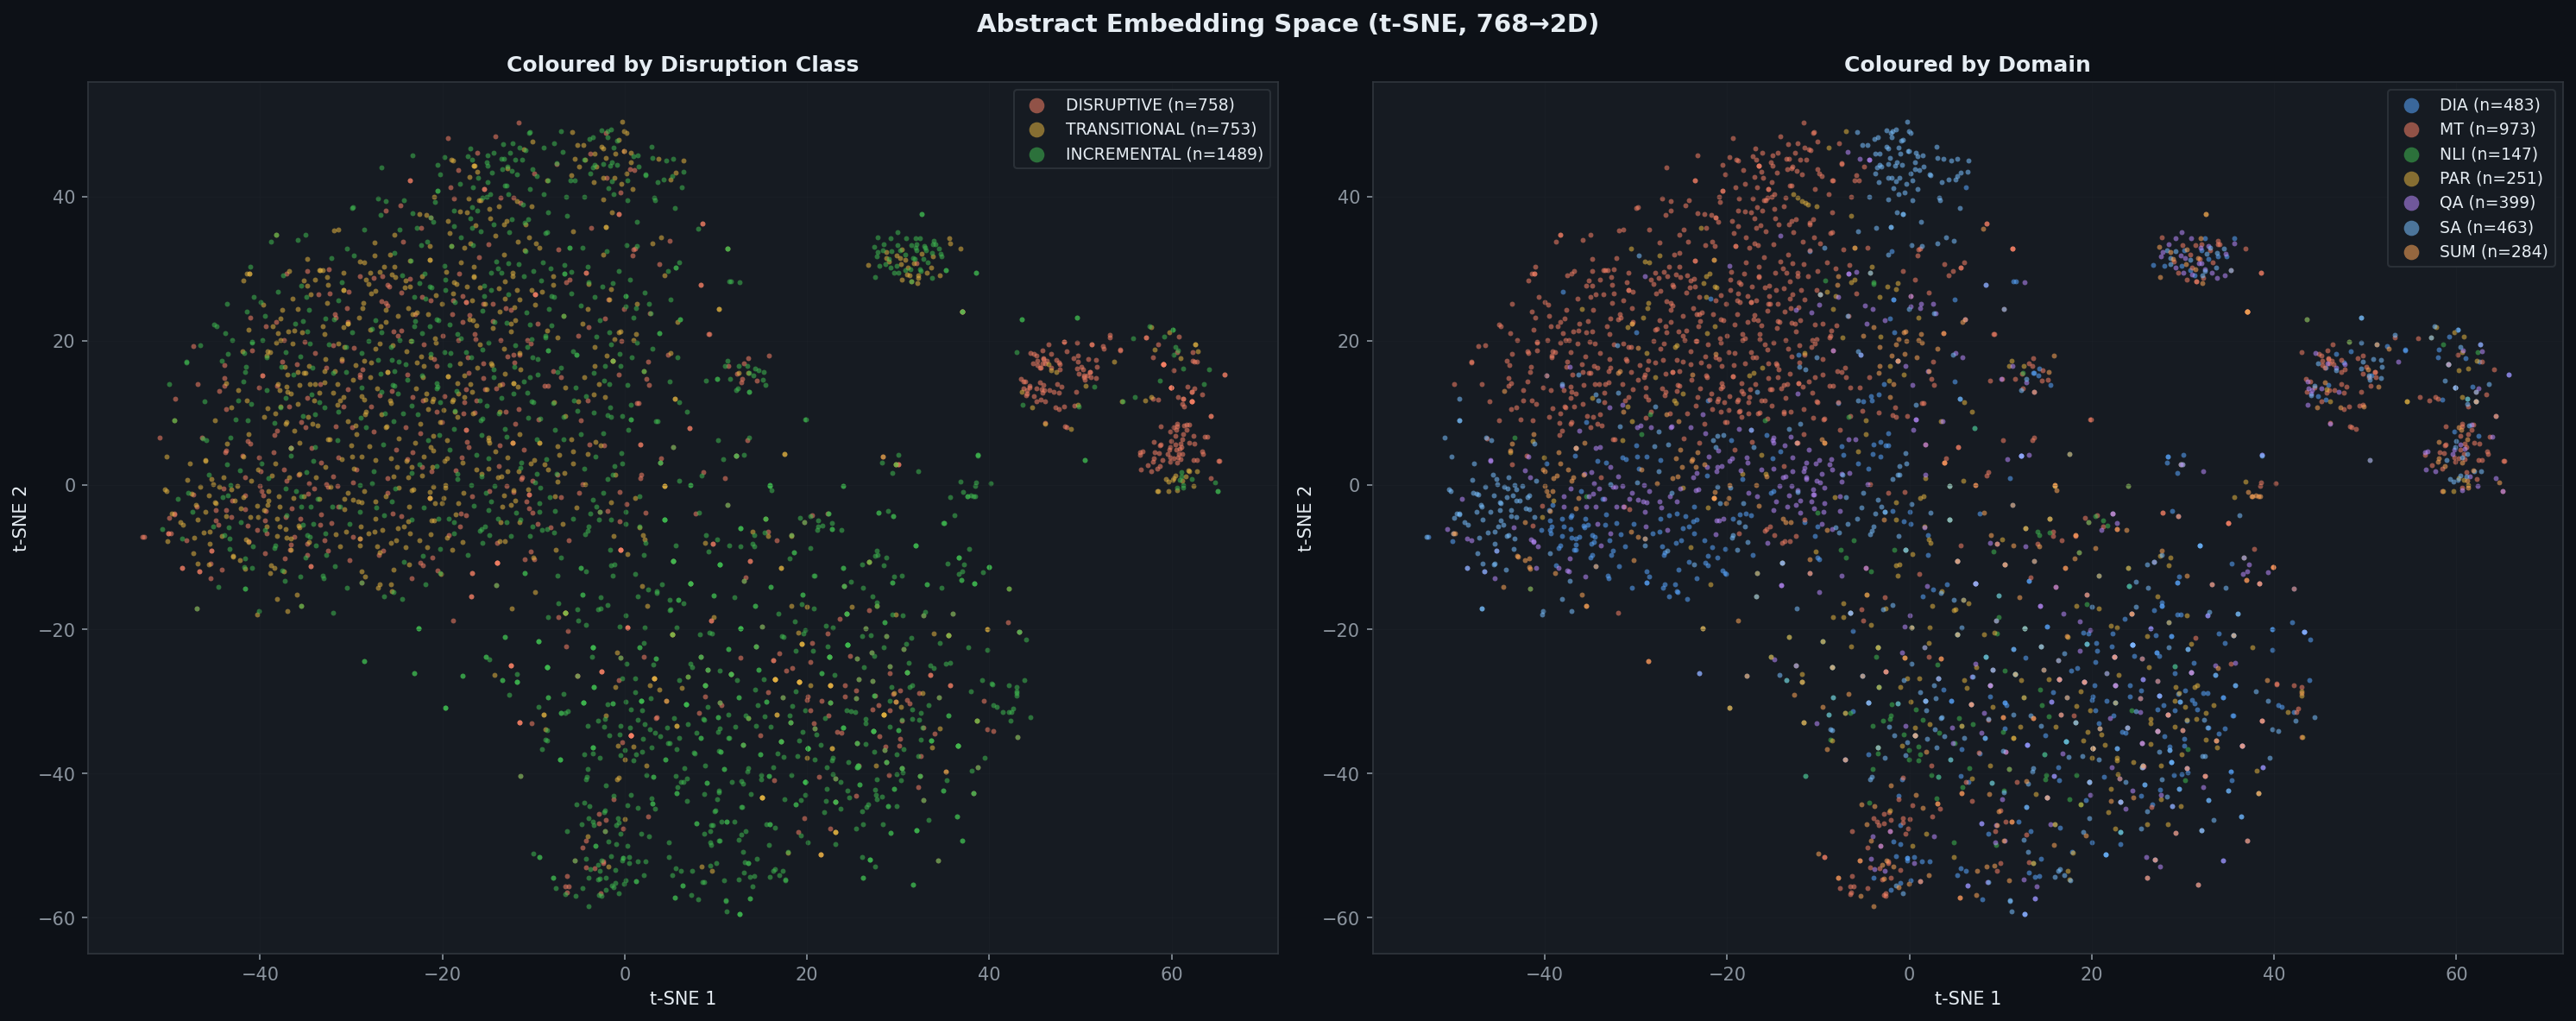

  ✓ saved → ../../outputs/visuals/5_4_tsne_clusters.png


In [9]:
print('Running t-SNE on abstract embeddings (this may take 1-3 min)...')

# ── Align embeddings with feature matrix ─────────────────────────────────────
pid_to_idx = {pid: i for i, pid in enumerate(paper_ids)}
valid_mask = df['paper_id'].isin(pid_to_idx)
df_emb     = df[valid_mask].copy().reset_index(drop=True)
emb_matrix = np.stack([abstract_emb[pid_to_idx[pid]] for pid in df_emb['paper_id']])

# Sub-sample for speed if large
MAX_TSNE = 3000
if len(df_emb) > MAX_TSNE:
    idx_sample = np.random.choice(len(df_emb), MAX_TSNE, replace=False)
    idx_sample = np.sort(idx_sample)
    df_emb     = df_emb.iloc[idx_sample].reset_index(drop=True)
    emb_matrix = emb_matrix[idx_sample]
    print(f'  Sub-sampled to {MAX_TSNE} papers for t-SNE')

# ── Run t-SNE ────────────────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, verbose=1, init='pca')
coords = tsne.fit_transform(emb_matrix)
df_emb['tsne_x'] = coords[:, 0]
df_emb['tsne_y'] = coords[:, 1]
print('t-SNE complete.')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Abstract Embedding Space (t-SNE, 768→2D)', fontsize=14, fontweight='bold')

# ── Panel A: Disruption class ────────────────────────────────────────────────
ax = axes[0]
for cls, color in CLASS_COLORS.items():
    mask = df_emb['disruption_class'] == cls
    if mask.sum() == 0:
        continue
    ax.scatter(df_emb.loc[mask, 'tsne_x'], df_emb.loc[mask, 'tsne_y'],
               c=color, s=8, alpha=0.55, label=f'{cls} (n={mask.sum()})',
               linewidths=0)
ax.set_title('Coloured by Disruption Class')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(markerscale=3, fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel B: Domain ──────────────────────────────────────────────────────────
ax = axes[1]
domains = sorted(df_emb['domain'].dropna().unique())
for i, dom in enumerate(domains):
    color = DOMAIN_PALETTE[i % len(DOMAIN_PALETTE)]
    mask  = df_emb['domain'] == dom
    ax.scatter(df_emb.loc[mask, 'tsne_x'], df_emb.loc[mask, 'tsne_y'],
               c=color, s=8, alpha=0.55, label=f'{dom} (n={mask.sum()})',
               linewidths=0)
ax.set_title('Coloured by Domain')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(markerscale=3, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save('5_4_tsne_clusters.png')

## Cell 6 — Plot 5.5: TransE vs TGN Unexpectedness Scatter
Each NOVEL paper plotted in the 2D unexpectedness space.
Quadrants:
- Q1 (high TransE, high TGN): structurally AND temporally novel
- Q2 (low TransE, high TGN): temporally novel (citation pattern)
- Q3 (high TransE, low TGN): structurally novel (KG geometry)
- Q4 (low both): incremental

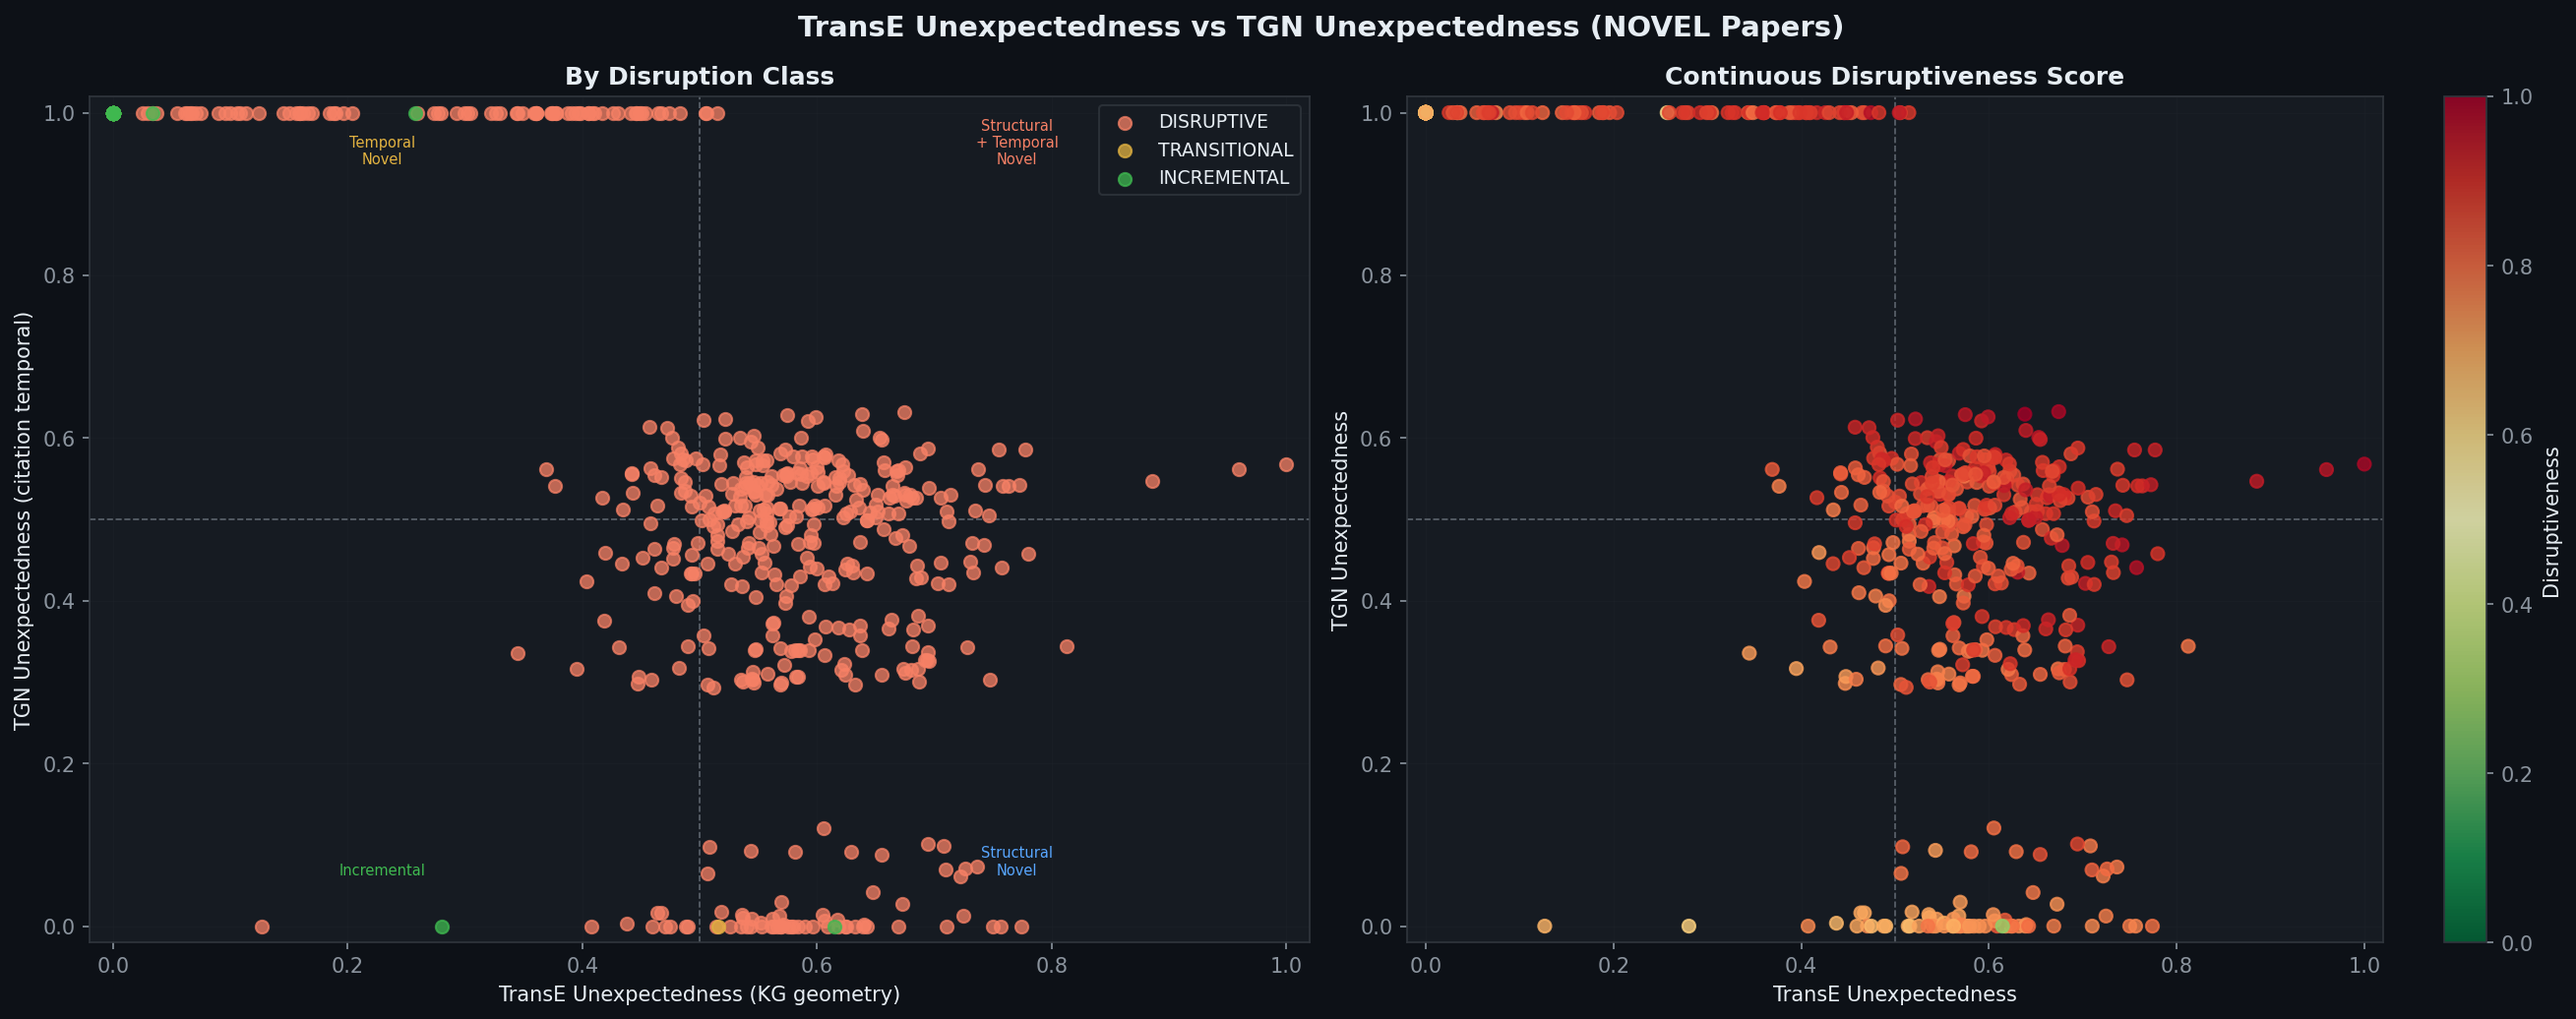

  ✓ saved → ../../outputs/visuals/5_5_transe_vs_tgn_scatter.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('TransE Unexpectedness vs TGN Unexpectedness (NOVEL Papers)',
             fontsize=14, fontweight='bold')

novel_df = df_novel.dropna(subset=['transe_unexpectedness','tgn_unexpectedness'])
# Only keep papers that actually got scored (non-zero)
novel_scored = novel_df[
    (novel_df['transe_unexpectedness'] > 0) |
    (novel_df['tgn_unexpectedness'] > 0)
].copy()

# ── Panel A: coloured by disruption_class ────────────────────────────────────
ax = axes[0]
for cls, color in CLASS_COLORS.items():
    mask = novel_scored['disruption_class'] == cls
    ax.scatter(novel_scored.loc[mask, 'transe_unexpectedness'],
               novel_scored.loc[mask, 'tgn_unexpectedness'],
               c=color, s=40, alpha=0.75, label=cls, zorder=3)

# Quadrant lines
ax.axvline(0.5, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axhline(0.5, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.6)
ax.text(0.76, 0.92, 'Structural\n+ Temporal\nNovel', fontsize=7,
        color='#f78166', ha='center', transform=ax.transAxes)
ax.text(0.24, 0.92, 'Temporal\nNovel', fontsize=7,
        color='#e3b341', ha='center', transform=ax.transAxes)
ax.text(0.76, 0.08, 'Structural\nNovel', fontsize=7,
        color='#58a6ff', ha='center', transform=ax.transAxes)
ax.text(0.24, 0.08, 'Incremental', fontsize=7,
        color='#3fb950', ha='center', transform=ax.transAxes)

ax.set_xlabel('TransE Unexpectedness (KG geometry)')
ax.set_ylabel('TGN Unexpectedness (citation temporal)')
ax.set_title('By Disruption Class')
ax.legend(fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

# ── Panel B: coloured by disruptiveness (continuous) ─────────────────────────
ax = axes[1]
sc = ax.scatter(novel_scored['transe_unexpectedness'],
                novel_scored['tgn_unexpectedness'],
                c=novel_scored['disruptiveness'],
                cmap='RdYlGn_r', s=40, alpha=0.8,
                vmin=0, vmax=1, zorder=3)
ax.axvline(0.5, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axhline(0.5, color='#8b949e', linewidth=0.8, linestyle='--', alpha=0.6)
plt.colorbar(sc, ax=ax, label='Disruptiveness')
ax.set_xlabel('TransE Unexpectedness')
ax.set_ylabel('TGN Unexpectedness')
ax.set_title('Continuous Disruptiveness Score')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save('5_5_transe_vs_tgn_scatter.png')

## Cell 7 — Plot 5.6: Top-20 Most Disruptive Papers

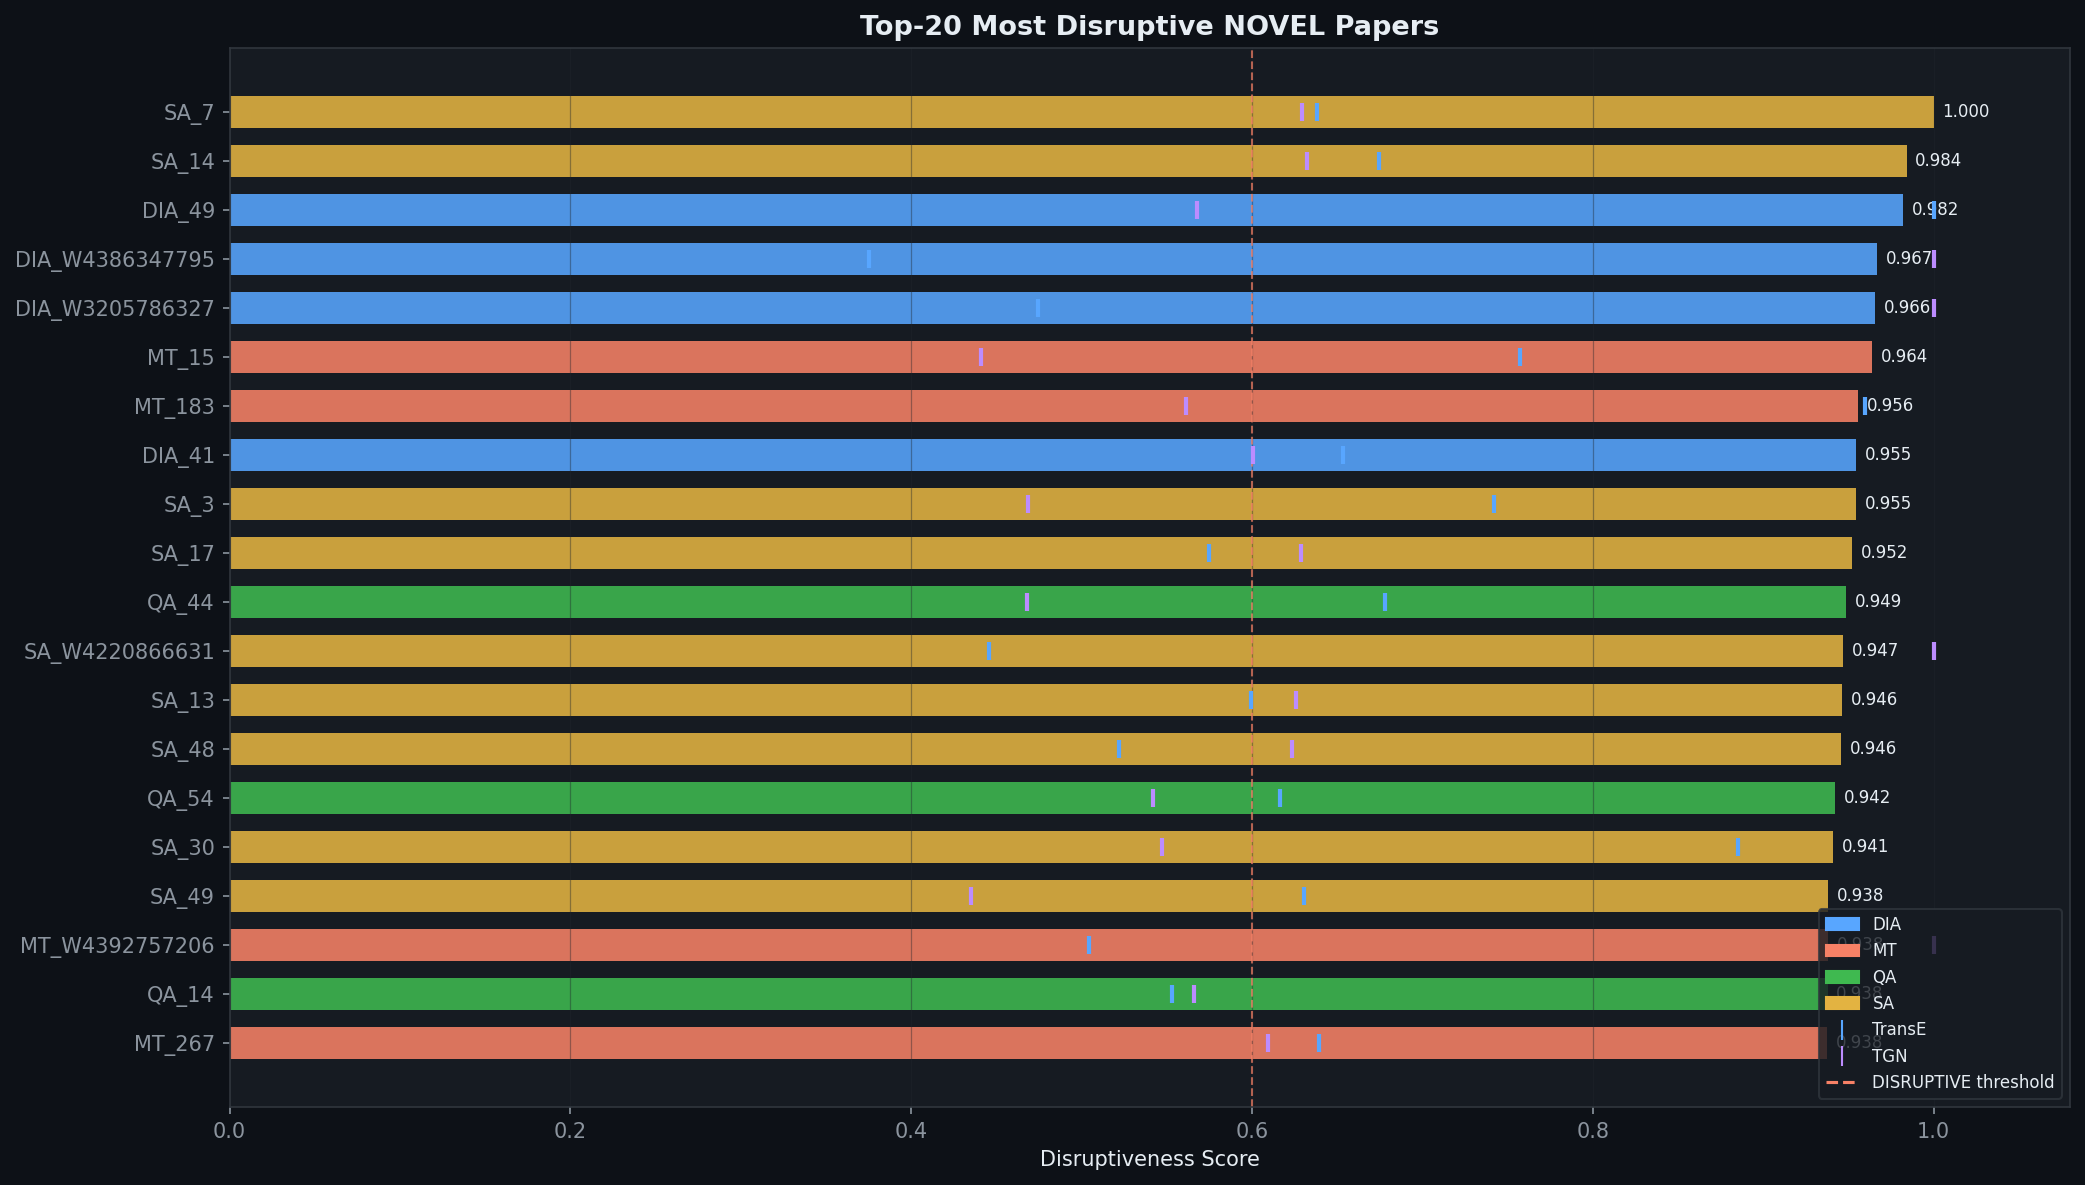

  ✓ saved → ../../outputs/visuals/5_6_top20_disruptive.png


In [11]:
top20 = combined.sort_values('disruptiveness', ascending=False).head(20).copy()
top20['label'] = top20['paper_id'].str.replace('NOVEL_', '', regex=False)

# Color each bar by domain
top20['dom'] = top20['paper_id'].str.split('_').str[1].fillna('UNK')
domains_list = sorted(top20['dom'].unique())
dom_color    = {d: DOMAIN_PALETTE[i % len(DOMAIN_PALETTE)] for i, d in enumerate(domains_list)}
bar_colors   = [dom_color[d] for d in top20['dom']]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top20['label'][::-1], top20['disruptiveness'][::-1],
               color=bar_colors[::-1], alpha=0.88, height=0.65)

# Overlay TransE and TGN as thin markers
transe_vals = top20['transe_unexpectedness'].fillna(0).values[::-1]
tgn_vals    = top20['tgn_unexpectedness'].fillna(0).values[::-1]
y_pos = range(len(top20))
ax.scatter(transe_vals, y_pos, marker='|', color='#58a6ff', s=80,
           zorder=5, label='TransE unexp.', linewidths=2)
ax.scatter(tgn_vals, y_pos, marker='|', color='#bc8cff', s=80,
           zorder=5, label='TGN unexp.', linewidths=2)

# Annotations on bars
for i, (bar, val) in enumerate(zip(bars, top20['disruptiveness'][::-1])):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, color='#e6edf3')

ax.axvline(0.6, color='#f78166', linewidth=1, linestyle='--', alpha=0.7, label='DISRUPTIVE threshold')
ax.set_xlabel('Disruptiveness Score')
ax.set_title('Top-20 Most Disruptive NOVEL Papers', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.08)
ax.grid(True, axis='x', alpha=0.4)
ax.legend(fontsize=9, loc='lower right')

# Domain legend
dom_patches = [mpatches.Patch(color=c, label=d) for d, c in dom_color.items()]
ax.legend(handles=dom_patches + [
    plt.Line2D([0],[0], marker='|', color='#58a6ff', label='TransE', markersize=10, linewidth=0),
    plt.Line2D([0],[0], marker='|', color='#bc8cff', label='TGN',    markersize=10, linewidth=0),
    plt.Line2D([0],[0], color='#f78166', linestyle='--', label='DISRUPTIVE threshold'),
], fontsize=8, loc='lower right')

plt.tight_layout()
save('5_6_top20_disruptive.png')

## Cell 8 — Plot 5.7: Domain × Year Disruptiveness Heatmap

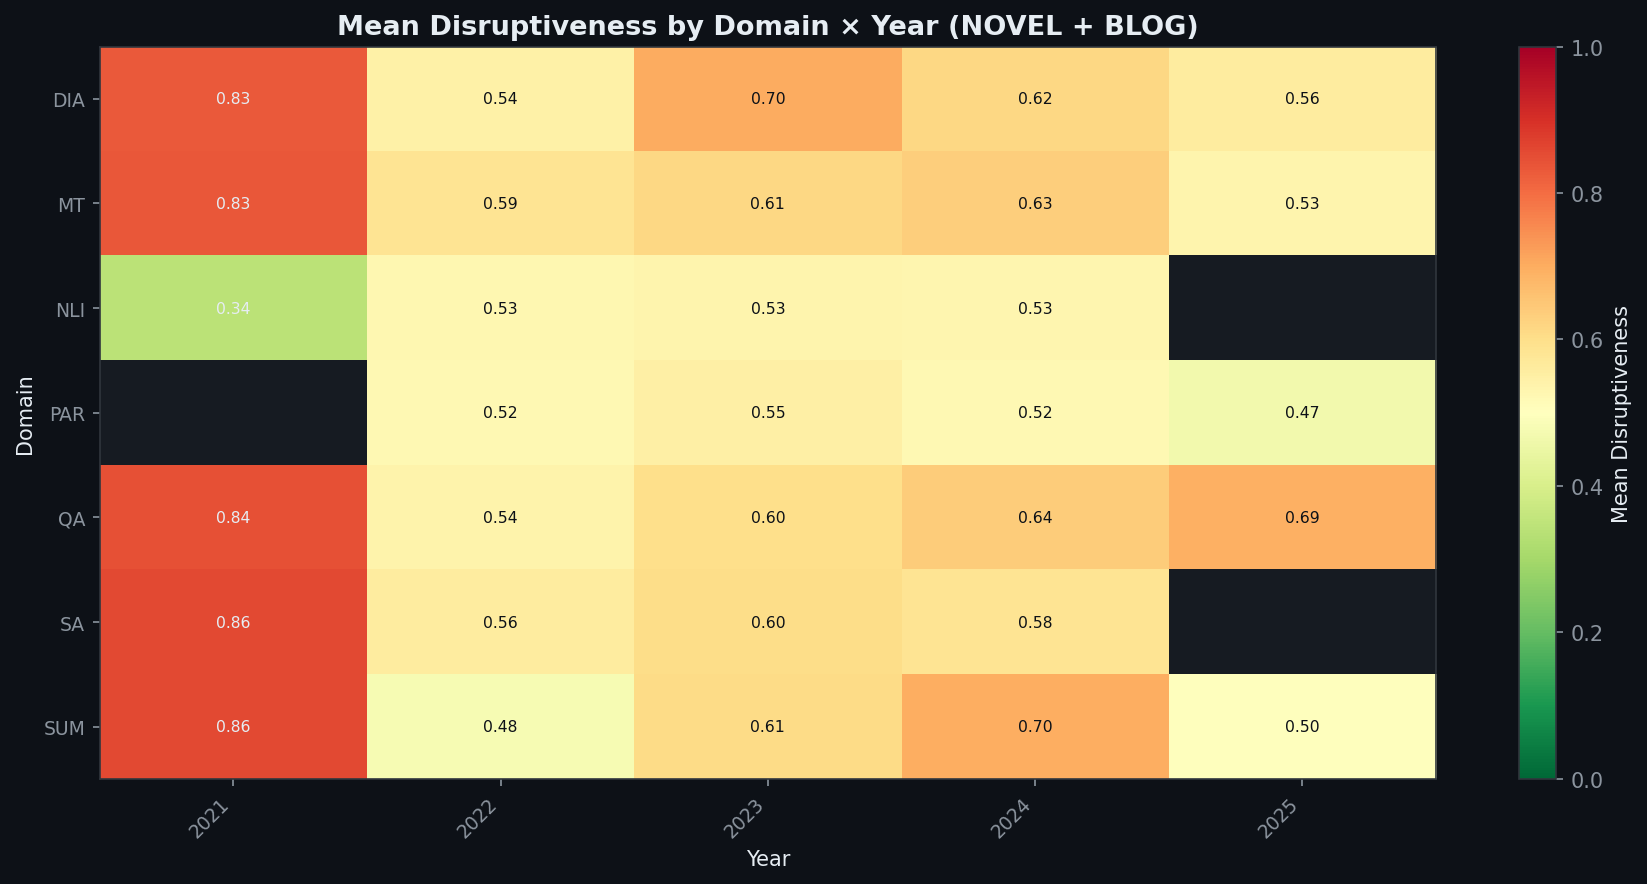

  ✓ saved → ../../outputs/visuals/5_7_domain_year_heatmap.png


In [12]:
# Only NOVEL + BLOG for heatmap (interesting era)
df_hmap = df[df['split'].isin(['NOVEL','BLOG'])].copy()
df_hmap['year_int'] = df_hmap['year'].fillna(0).astype(int)

pivot = df_hmap.pivot_table(
    values='disruptiveness', index='domain', columns='year_int',
    aggfunc='mean'
)
# Keep years with enough data
col_counts = df_hmap.groupby('year_int').size()
keep_years = col_counts[col_counts >= 5].index
pivot = pivot[sorted(set(pivot.columns) & set(keep_years))]
# Drop domains with too many NaNs
pivot = pivot.dropna(thresh=max(1, len(pivot.columns)//2))

fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns)*0.9),
                                max(6,  len(pivot.index)*0.7)))

im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Cell annotations
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7.5,
                    color='#0d1117' if 0.35 < val < 0.75 else '#e6edf3')

plt.colorbar(im, ax=ax, label='Mean Disruptiveness')
ax.set_title('Mean Disruptiveness by Domain × Year (NOVEL + BLOG)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Domain')

plt.tight_layout()
save('5_7_domain_year_heatmap.png')

## Cell 9 — Summary Statistics CSV

In [13]:
rows = []
score_cols = ['struct_norm','semantic_norm','composite_novelty',
              'transe_unexpectedness','tgn_unexpectedness',
              'kg_unexpectedness','disruptiveness']

for split_name in ['SKG','NOVEL','BLOG','ALL']:
    sub = df if split_name == 'ALL' else df[df['split'] == split_name]
    for col in score_cols:
        if col not in sub.columns:
            continue
        vals = sub[col].dropna()
        rows.append({
            'split'  : split_name,
            'metric' : col,
            'n'      : len(vals),
            'mean'   : round(vals.mean(), 4),
            'std'    : round(vals.std(),  4),
            'median' : round(vals.median(), 4),
            'p25'    : round(vals.quantile(0.25), 4),
            'p75'    : round(vals.quantile(0.75), 4),
            'min'    : round(vals.min(), 4),
            'max'    : round(vals.max(), 4),
        })

# Class distribution per split
class_rows = []
for split_name in ['SKG','NOVEL','BLOG']:
    sub = df[df['split'] == split_name]
    counts = sub['disruption_class'].value_counts()
    total  = len(sub)
    for cls in ['DISRUPTIVE','TRANSITIONAL','INCREMENTAL']:
        class_rows.append({
            'split': split_name, 'class': cls,
            'count': counts.get(cls, 0),
            'pct'  : round(100 * counts.get(cls, 0) / max(total, 1), 1)
        })

summary_df   = pd.DataFrame(rows)
class_dist   = pd.DataFrame(class_rows)

summary_df.to_csv(f'{OUT_DIR}/summary_statistics.csv', index=False)
class_dist.to_csv(f'{OUT_DIR}/class_distribution.csv', index=False)

print('=== Score Summary ===')
print(summary_df[summary_df['split']=='NOVEL'].to_string(index=False))
print()
print('=== Class Distribution ===')
print(class_dist.to_string(index=False))
print()
print('✓ summary_statistics.csv')
print('✓ class_distribution.csv')

print()
print('=== ALL VISUALS SAVED ===')
for f in sorted(os.listdir(OUT_DIR)):
    print(f'  {OUT_DIR}/{f}')

=== Score Summary ===
split                metric   n   mean    std  median    p25    p75    min    max
NOVEL           struct_norm 762 0.4679 0.3503  0.6636 0.0000 0.7300 0.0000 1.0000
NOVEL         semantic_norm 762 0.8374 0.0997  0.8522 0.8080 0.8833 0.1211 1.0000
NOVEL     composite_novelty 762 0.7255 0.1052  0.7592 0.6489 0.7986 0.1844 0.9106
NOVEL transe_unexpectedness 762 0.3463 0.2829  0.4756 0.0000 0.5836 0.0000 1.0000
NOVEL    tgn_unexpectedness 762 0.6461 0.3440  0.5634 0.4400 1.0000 0.0000 1.0000
NOVEL     kg_unexpectedness 762 0.4962 0.1272  0.5000 0.5000 0.5566 0.0000 0.7840
NOVEL        disruptiveness 762 0.7774 0.1176  0.8014 0.7048 0.8689 0.2151 1.0000

=== Class Distribution ===
split        class  count  pct
  SKG   DISRUPTIVE    388 13.3
  SKG TRANSITIONAL    964 33.1
  SKG  INCREMENTAL   1564 53.6
NOVEL   DISRUPTIVE    650 85.3
NOVEL TRANSITIONAL     31  4.1
NOVEL  INCREMENTAL     81 10.6
 BLOG   DISRUPTIVE     23  4.1
 BLOG TRANSITIONAL     65 11.5
 BLOG  INCREMEN